TENDENCIAS MUSICALES DEL SIGLO XXI: LA ERA DEL STREAMING  
¿Cómo ha evolucionado el consumo y la producción musical durante las últimas dos décadas?  
El objetivo principal de este proyecto es analizar la evolución de los hábitos de consumo y la producción musical durante las dos últimas décadas, extrayendo patrones estructurales que definen el éxito en la era digital para guiar estrategias de producción comercial y detención de audiencias.

Este análisis partirá de la siguiente base de datos que puede ser verificada a través de este link:
https://www.kaggle.com/datasets/amitanshjoshi/spotify-1million-tracks/data 
Para dicho análisis usaremos: SQL, Pandas, Matplotlibe y Seaborn que nos servirán para limpiar y consultar datos y su respectiva visualización.

In [23]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

El estilo que usaremos será "Dark Mode" y lo definimos de esta forma

In [25]:
plt.style.use('dark_background')
sns.set_palette(['#00d8ff', '#ff6600', '#aaaaaa']) 
plt.rcParams['figure.facecolor'] = '#121212'
plt.rcParams['axes.facecolor'] = '#121212'
plt.rcParams['axes.grid'] = False 
plt.rcParams['axes.edgecolor'] = '#333333'

Ahora comenzaremos la lectura de la base de datos que ha sido descargada y un mapeo de la columna "key" que tiene valores de 0 a 11 que representan las 12 tonalidades de la música, es decir, DO, DO#/REb, RE, RE#/MIb, MI, FA, FA#/SOLb, SOL, SOL#/LAb, LA, LA#/SIb  y SI

In [27]:
df = pd.read_csv('spotify_data.csv')

# Mapeamos los tonos de la API de Spotify a notación musical real
mapeo_tonos = {
    0: 'DO', 1: 'DO#/REb', 2: 'RE', 3: 'RE#/MIb', 4: 'MI', 5: 'FA', 
    6: 'FA#/SOLb', 7: 'SOL', 8: 'SOL#/LAb', 9: 'LA', 10: 'LA#/SIb', 11: 'SI'
}
# Creamos una columna nueva y legible
df['nota_musical'] = df['key'].map(mapeo_tonos)

In [28]:
conexion = sqlite3.connect(':memory:')
df.to_sql('spotify_db', conexion, index=False)

print(f"¡Base de datos cargada con {len(df)} canciones!")
print("Tonos musicales mapeados y motor SQL listo para consultas.")

¡Base de datos cargada con 1159764 canciones!
Tonos musicales mapeados y motor SQL listo para consultas.


El siguiente query es para hacer un conteo de cuántas canciones usan una nota como su centro tonal

In [30]:
QUERY = """
    SELECT nota_musical, COUNT(*) AS conteo
    FROM spotify_db GROUP BY nota_musical 
    ORDER BY conteo DESC
    """ 
df_tonos = pd.read_sql_query(QUERY, conexion)
print(df_tonos.head(12))

   nota_musical  conteo
0           SOL  139635
1            DO  130081
2            RE  123690
3            LA  119293
4       DO#/REb  112806
5            FA   94032
6            MI   91170
7            SI   90955
8      FA#/SOLb   76120
9       LA#/SIb   76038
10     SOL#/LAb   70206
11      RE#/MIb   35738


Vamos a visualizarlo mejor

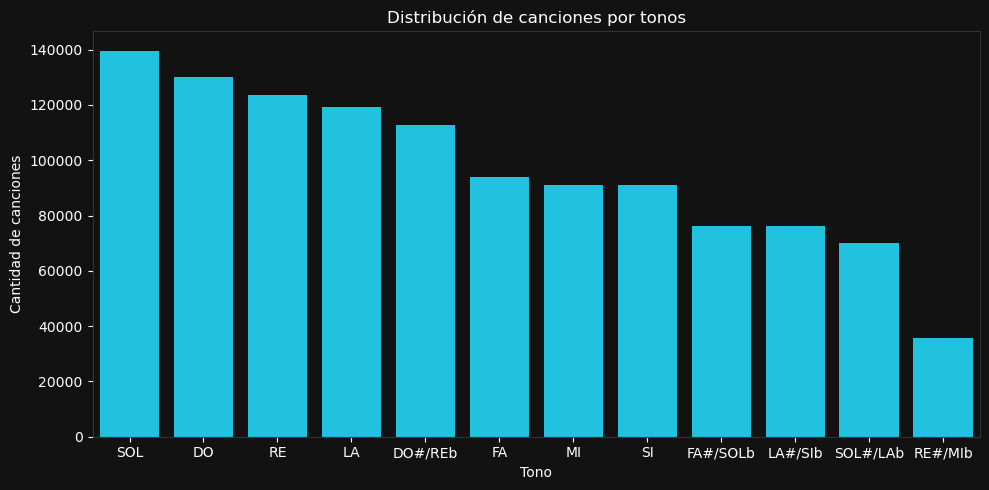

In [32]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_tonos,
    x='nota_musical',
    y='conteo',
    palette=["#00d8ff"]
)
plt.title('Distribución de canciones por tonos')
plt.xlabel('Tono')
plt.ylabel('Cantidad de canciones')
plt.tight_layout()
plt.show()

En esta gráfica de barras es posible notar que los cuatro tonos más populares son natualares, es decir, que presentan pocas alteraciones en su escala tanto mayor como menor, como, SOL, DO, RE y LA.  
Por otro lado, los cuatro tonos menos populares tienen más notas alteradas en escala. Esto puede deberse a que la mayoría de instrumentos de cuerda están afinados en tonos más natualares, como en la guitarra, lo que facilita la ejecución y escritura por parte de los músicos y compositores de forma respectiva al crear una canción.

Pero tenemos que ser más específicos porque un tono puede ser 'mayor' o 'menor', es decir puede ser G (GM) o Gm.  
Para explicar de mejor forma, las tonalidades mayores pueden sonar más "alegres" mientras que las menores más "apagadas" o "tristes". Entonces, cuando la tonalidad sea mayor usaremos una M y m para menor.  
En la base de datos tenemos la columna 'mode' que viene con dos números, 0 y 1 que representan menor y mayor respectivamente.

In [35]:
df['modo_de_tono'] = df['mode'].map({1: 'M', 0: 'm'})
df.to_sql('spotify_db', conexion, if_exists='replace', index=False)

1159764

Lo que haremos en el siguiente query será unificar la columna de 'nota_musical' (extraída anteriormente de 'key') y 'modo_de_tono' (hecha a partir de 'mode') y unificarlas en una sola columna llamada 'tonalidad' para juntar los valores de cada una y visualizar de mejor forma las tonalidades mayores y menores.

In [37]:
QUERY1 = """
    SELECT nota_musical, modo_de_tono, 
    (nota_musical || modo_de_tono) AS tonalidad,
    COUNT(*) AS conteo
    FROM spotify_db
    GROUP BY nota_musical, modo_de_tono
    ORDER BY conteo DESC
    """
df_tonos_modo = pd.read_sql_query(QUERY1, conexion)

In [38]:
print("Columnas de df_tonos_modo:", df_tonos_modo.columns.tolist()) 
print(df_tonos_modo.head())

Columnas de df_tonos_modo: ['nota_musical', 'modo_de_tono', 'tonalidad', 'conteo']
  nota_musical modo_de_tono tonalidad  conteo
0          SOL            M      SOLM  108715
1           DO            M       DOM  101824
2           RE            M       REM   95027
3      DO#/REb            M  DO#/REbM   80219
4           LA            M       LAM   69237


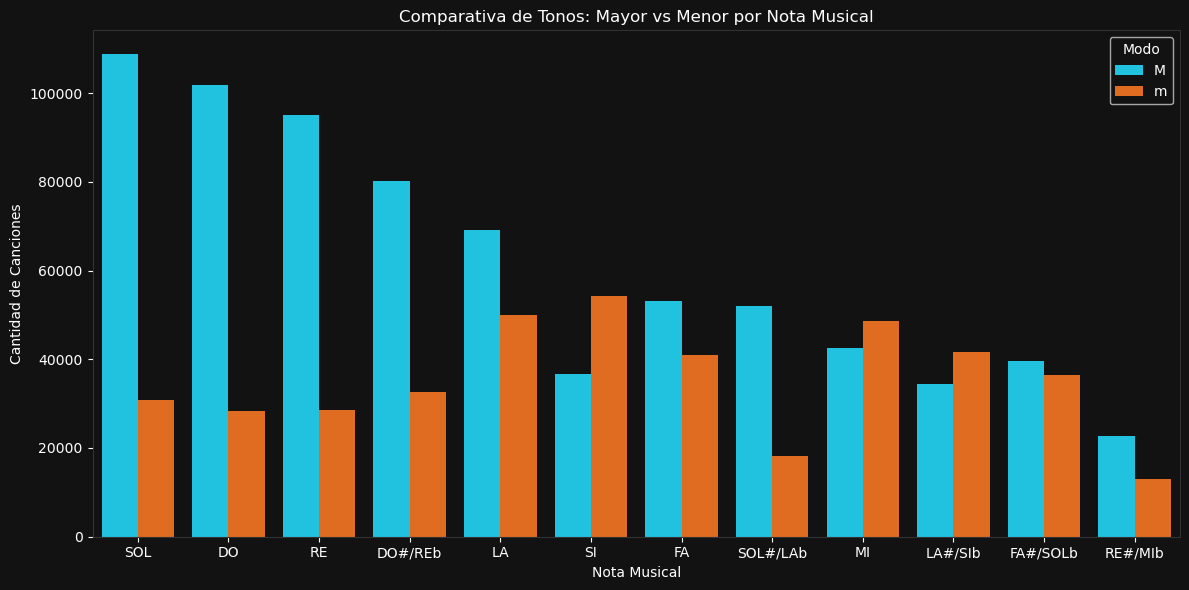

In [39]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_tonos_modo,
    x='nota_musical',
    y='conteo',
    hue='modo_de_tono',
    palette=['#00d8ff', '#ff6600']
)
plt.title('Comparativa de Tonos: Mayor vs Menor por Nota Musical')
plt.xlabel('Nota Musical') 
plt.ylabel('Cantidad de Canciones') 
plt.legend(title='Modo') 
plt.tight_layout() 
plt.show()

Con este gráfico podemos reafirmar la información del primero: las tonalidades más populares son las que tienen menos alteraciones.  
-SOL tiene una alteración en su forma mayor y dos en su forma menor.  
-DO no tiene alteraciones su escala mayor y tres en su escala menor.  
-RE tiene dos alteraciones en su escala mayor y una en su escala menor.  
-LA tiene tres alteraciones en su escala mayor y ninguna en su escala menor (Sí, Do mayor y La menor natural usan la misma escala)
No obstante, DO# mayor que tiene todas sus notas alteradas (7) es más usado que La mayor, esto podría pasar porque la tonalidad de DO# es igual a la de DO que no tiene sostenidos, es decir, la escala de DO# mayor es alterar todas las notas de DO mayor.

Por otro lado tonos como SI, MI y LA#/SIb suelen ser más menores que mayores, esto se puede explicar otra vez con la cantidad de alteraciones en sus escalas.  
-SI mayor tiene 5 alteraciones, mientras que su escala menor tiene 2, las mismas que las de RE mayor.  
-MI mayor tiene 4 alteraciones, mientras que su escala menor tiene 1, las mismas que las de SOL mayor.  
Pero aquí tenemos otra paradoja, SIb tiene solo dos alteraciones en su escala mayor, pero tiene 5 en su escala menor y esta última es más usada.  
La elección de la tonalidad tiene muchos factores: tipo de voz del cantante, faciliadad para ejecutar en ciertos tipos de instrumentos y elección del compositor para transmitir algo en específico.

Los siguientes artistas 'Don Omar','Daddy Yankee' y 'Wisin & Yandel' aparecen como artistas de Hip-Hop pero realmente son representantes del Reggaeton, por lo que les asignaremos su género correspondiente.

In [43]:
QUERY3 = """
    UPDATE spotify_db SET genre='reggaeton' 
    WHERE artist_name IN ('Don Omar','Daddy Yankee','Wisin & Yandel')
    """
conexion.execute(QUERY3) 
conexion.commit()
print("¡Artistas actualizados a reggaeton con éxito!")

¡Artistas actualizados a reggaeton con éxito!


In [44]:
QUERY_VERIFICAR = """ 
    SELECT artist_name, genre, track_name 
    FROM spotify_db 
    WHERE artist_name IN ('Don Omar', 'Daddy Yankee', 'Wisin & Yandel') 
    """ 
reggaeton = pd.read_sql_query(QUERY_VERIFICAR, conexion) 
print(reggaeton.head(10))

      artist_name      genre           track_name
0  Wisin & Yandel  reggaeton  Algo Me Gusta De Ti
1  Wisin & Yandel  reggaeton    Follow The Leader
2  Wisin & Yandel  reggaeton          Hipnotízame
3  Wisin & Yandel  reggaeton            Tu Nombre
4  Wisin & Yandel  reggaeton       Vengo Acabando
5  Wisin & Yandel  reggaeton               Perdón
6  Wisin & Yandel  reggaeton              Peligro
7  Wisin & Yandel  reggaeton       No Te Detengas
8  Wisin & Yandel  reggaeton              Un Beso
9  Wisin & Yandel  reggaeton         Música Buena


Lo mismo haremos con artistas populares que canan Pop pero están catalogados como Spanish.
No haremos esto con todos los artistas hispanoparlantes, porque la intención de la base de datos también es mostrar los idiomas más escuchados en canciones.

In [46]:
QUERY4 = """
    SELECT DISTINCT artist_name, genre 
    FROM spotify_db WHERE 
    genre = 'spanish'
    """
spanish_artists = pd.read_sql_query(QUERY4, conexion) 
print(spanish_artists)

             artist_name    genre
0          Pablo Alborán  spanish
1         Antonio Orozco  spanish
2                Melendi  spanish
3     La Quinta Estacion  spanish
4                   Malú  spanish
...                  ...      ...
1332          Zurrumalla  spanish
1333         Estereotypo  spanish
1334              Orlean  spanish
1335             Showpay  spanish
1336     Lilian De Celis  spanish

[1337 rows x 2 columns]


In [47]:
QUERY5 = """
    UPDATE spotify_db SET genre='pop' 
    WHERE artist_name IN ('La Oreja de Van Gogh','Pablo Alborán','La Quinta Estacion')
    """
conexion.execute(QUERY5) 
conexion.commit()
print("¡Artistas españoles actualizados a pop con éxito!")

¡Artistas españoles actualizados a pop con éxito!


A partir de aquí veremos las principales tendencias por lustro, es decir, veremos los 20 géneros musicales más escuchados en streming cada cinco años.
Para eso, modificaremos la tabla y crearemos una columna llamada 'etiqueta_lustro' con SQL.

In [49]:
# 1. Creamos la columna vacía en la base de datos
conexion.execute("ALTER TABLE spotify_db ADD COLUMN etiqueta_lustro TEXT")

# 2. Llenamos la columna fila por fila usando la lógica matemática de SQL
conexion.execute("""
    UPDATE spotify_db 
    SET etiqueta_lustro = (year - (year % 5)) || '-' || ((year - (year % 5)) + 4)
""")

# Guardamos los cambios en la base de datos
conexion.commit()

print("¡Columna 'etiqueta_lustro' creada y guardada permanentemente en SQL!")

¡Columna 'etiqueta_lustro' creada y guardada permanentemente en SQL!


In [50]:
QUERY6 = """
    SELECT genre, SUM(popularity) AS popularity_total, etiqueta_lustro 
    FROM spotify_db 
    WHERE etiqueta_lustro = '2000-2004'
    GROUP BY genre
    ORDER BY popularity_total DESC
    LIMIT 20
    """
lustro00_04 = pd.read_sql_query(QUERY6, conexion)
lustro00_04

,genre,popularity_total,etiqueta_lustro
0,alt-rock,153117,2000-2004
1,dance,124371,2000-2004
2,classical,94115,2000-2004
3,country,89426,2000-2004
4,hardcore,86816,2000-2004
5,hip-hop,80543,2000-2004
6,folk,78961,2000-2004
7,jazz,73287,2000-2004
8,blues,67024,2000-2004
9,pop,66484,2000-2004


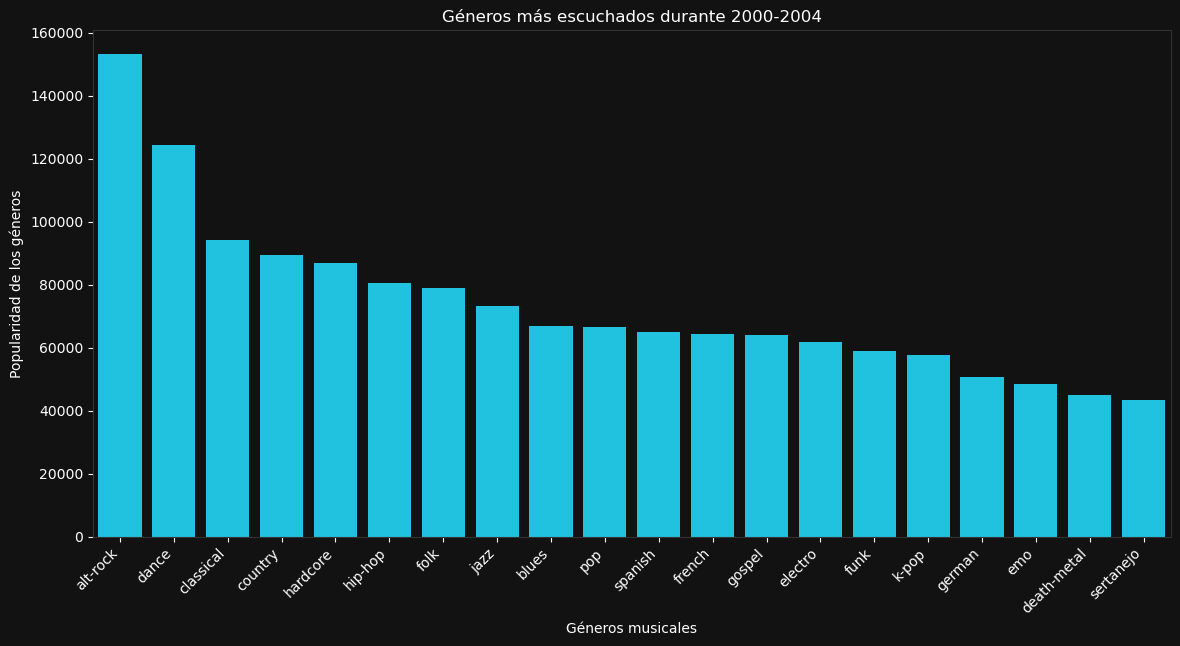

In [51]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=lustro00_04,
    x="genre",
    y="popularity_total",
    palette=['#00d8ff']
)
plt.title('Géneros más escuchados durante 2000-2004')
plt.xlabel('Géneros musicales') 
plt.ylabel('Popularidad de los géneros') 
#plt.legend(title='Modo') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

En este gráfico es posible apreciar que el rock alternativo está en el top 1, no obstante puede sorprender que la música clásica esté en el puesto 3, ya que en muchas ocasiones pueden existir mitos como que es la menos "apreciada" o "escuchada".  
También canciones en otros idiomas como español, francés, coreano (k-pop), alemán y portugués con el Sertanejo de Brasil fueron tendencias musicales en países donde no se hablan dichos idiomas.

In [53]:
QUERY7 = """
    SELECT genre, SUM(popularity) AS popularity_total, etiqueta_lustro 
    FROM spotify_db 
    WHERE etiqueta_lustro = '2005-2009'
    GROUP BY genre
    ORDER BY popularity_total DESC
    LIMIT 20
    """
lustro05_09 = pd.read_sql_query(QUERY7, conexion)
lustro05_09

,genre,popularity_total,etiqueta_lustro
0,alt-rock,159463,2005-2009
1,dance,133709,2005-2009
2,hip-hop,109232,2005-2009
3,country,98287,2005-2009
4,folk,91888,2005-2009
5,classical,89847,2005-2009
6,jazz,82637,2005-2009
7,spanish,78656,2005-2009
8,blues,78358,2005-2009
9,electro,77979,2005-2009


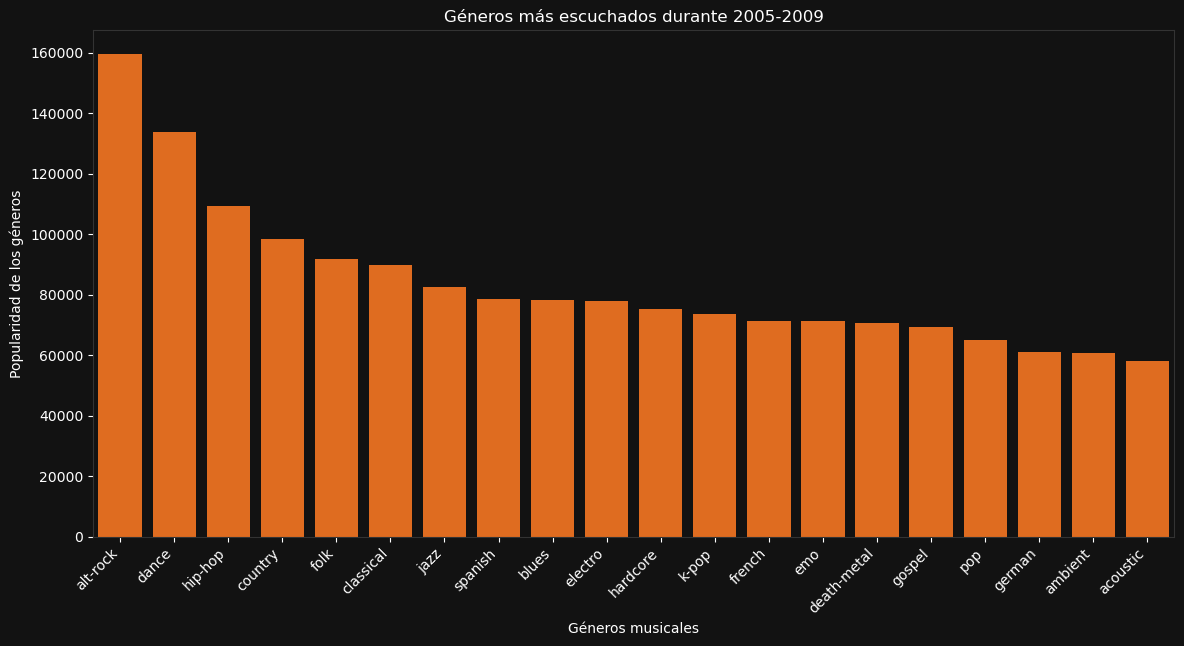

In [54]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=lustro05_09,
    x="genre",
    y="popularity_total",
    palette=['#ff6600']
)
plt.title('Géneros más escuchados durante 2005-2009')
plt.xlabel('Géneros musicales') 
plt.ylabel('Popularidad de los géneros') 
#plt.legend(title='Modo') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

-Los géneros Ambient y Acoustic desplazan al Funk y Sertanejo en el TOP 20 de este lustro.  
-Mientras que el Emo y Death-metal toman más fuerza que el lustro pasado.  
-Por otro lado, música en otros idiomas, español, francés y alemán suben un poco más la tendencia con respecto al lustro anterior.

In [56]:
QUERY8 = """
    SELECT genre, SUM(popularity) AS popularity_total, etiqueta_lustro 
    FROM spotify_db 
    WHERE etiqueta_lustro = '2010-2014'
    GROUP BY genre
    ORDER BY popularity_total DESC
    LIMIT 20
    """
lustro10_14 = pd.read_sql_query(QUERY8, conexion)
lustro10_14

,genre,popularity_total,etiqueta_lustro
0,alt-rock,168311,2010-2014
1,dance,158718,2010-2014
2,hip-hop,142455,2010-2014
3,country,127246,2010-2014
4,folk,112072,2010-2014
5,k-pop,107676,2010-2014
6,chill,106093,2010-2014
7,emo,97723,2010-2014
8,classical,95808,2010-2014
9,french,94113,2010-2014


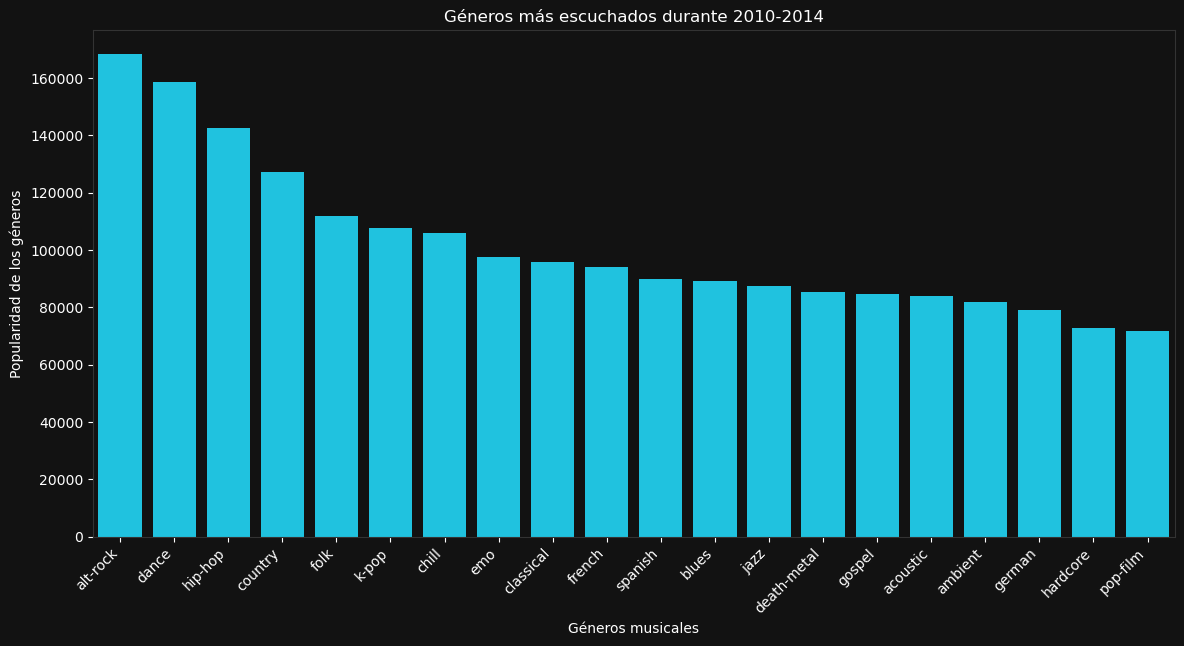

In [57]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=lustro10_14,
    x="genre",
    y="popularity_total",
    palette=['#00d8ff']
)
plt.title('Géneros más escuchados durante 2010-2014')
plt.xlabel('Géneros musicales') 
plt.ylabel('Popularidad de los géneros') 
#plt.legend(title='Modo') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

-El Chill aparece dentro del TOP 10 en tendencias de este lustro, por otro lado, el Pop-Film hace su aparición en el TOP 20.  
-La música producida en francés supera a las producidas en español.

In [59]:
QUERY9 = """
    SELECT genre, SUM(popularity) AS popularity_total, etiqueta_lustro 
    FROM spotify_db 
    WHERE etiqueta_lustro = '2015-2019'
    GROUP BY genre
    ORDER BY popularity_total DESC
    LIMIT 20
    """
lustro15_19 = pd.read_sql_query(QUERY9, conexion)
lustro15_19

,genre,popularity_total,etiqueta_lustro
0,hip-hop,223734,2015-2019
1,alt-rock,195231,2015-2019
2,chill,179521,2015-2019
3,dance,176433,2015-2019
4,k-pop,167672,2015-2019
5,emo,154238,2015-2019
6,folk,149024,2015-2019
7,country,144133,2015-2019
8,ambient,138828,2015-2019
9,french,137505,2015-2019


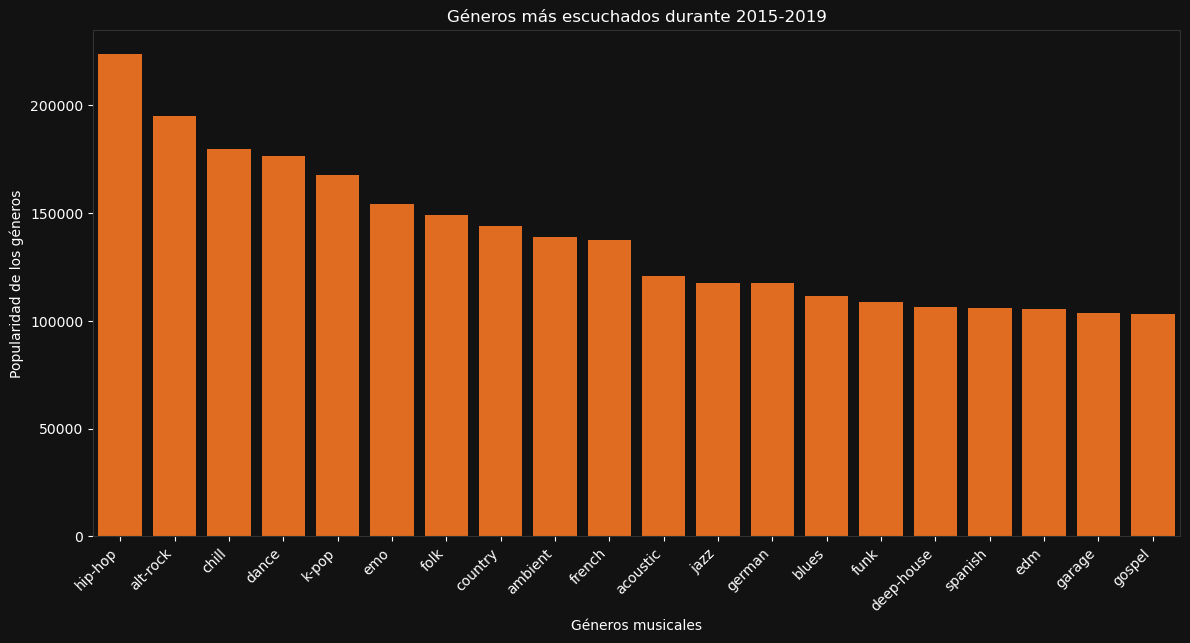

In [60]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=lustro15_19,
    x="genre",
    y="popularity_total",
    palette=['#ff6600']
)
plt.title('Géneros más escuchados durante 2015-2019')
plt.xlabel('Géneros musicales') 
plt.ylabel('Popularidad de los géneros') 
#plt.legend(title='Modo') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

En este lustro el Alt-Rock pierde el liderato frente al Hip-Hop, mientras que el K-Pop  y el Chill entra en el TOP 5.  
-El Funk reaparece en el TOP 20.  
-Las canciones en francés y alemán a las canciones en español.  
-El Deep-House, EDM y Garage entran en el TOP 20 Global.  
-El Death-Metal, Ambient, Música Clásica y Hardcore desaparecen del TOP 20.

In [62]:
QUERY10 = """
    SELECT genre, SUM(popularity) AS popularity_total, etiqueta_lustro 
    FROM spotify_db 
    WHERE etiqueta_lustro = '2020-2024'
    GROUP BY genre
    ORDER BY popularity_total DESC
    LIMIT 20
    """
lustro20_24 = pd.read_sql_query(QUERY10, conexion)
lustro20_24

,genre,popularity_total,etiqueta_lustro
0,hip-hop,162012,2020-2024
1,chill,156939,2020-2024
2,k-pop,148184,2020-2024
3,dance,147476,2020-2024
4,country,131895,2020-2024
5,alt-rock,131246,2020-2024
6,sad,127656,2020-2024
7,jazz,124212,2020-2024
8,french,122721,2020-2024
9,emo,121298,2020-2024


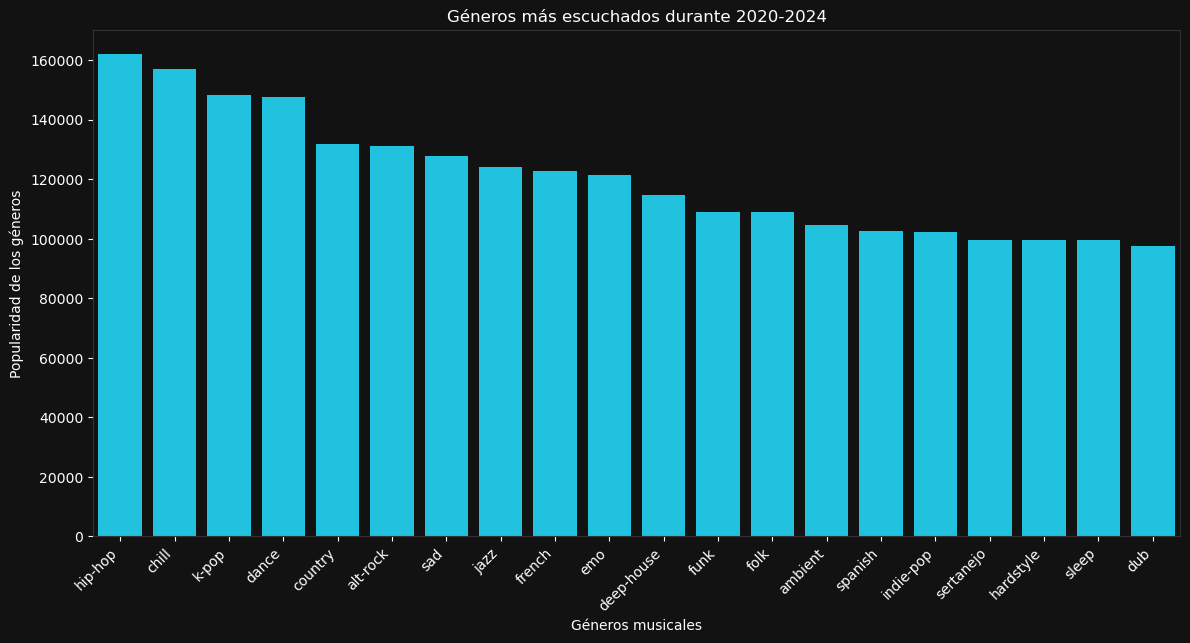

In [63]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=lustro20_24,
    x="genre",
    y="popularity_total",
    palette=['#00d8ff']
)
plt.title('Géneros más escuchados durante 2020-2024')
plt.xlabel('Géneros musicales') 
plt.ylabel('Popularidad de los géneros') 
#plt.legend(title='Modo') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

-El Alt-Rock no está en el TOP 5 por primera vez.  
-La música Sad entra dentro del TOP 10.  
-Los géneros Sleep, Hardstyle, Dub e Indie-Pop entran en el TOP 20.  
-Por primera vez la música producida en alemán y el Gospel no están dentro del TOP 20.  
-El Sertanejo y Ambient reaparecen en el TOP 20.  
-Por primera vez el Folk queda fuera del TOP 10.  
-El Hip-Hop fue el género más escuchado, aún así, no rompió su récord del año pasado cuando pasó del umbral de 200K (hay que tener en cuenta que falta el año 2024 ya que los datos llegan hasta el 2023).

In [65]:
df.columns

Index(['Unnamed: 0', 'artist_name', 'track_name', 'track_id', 'popularity',
       'year', 'genre', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'nota_musical',
       'modo_de_tono'],
      dtype='object')

En este punto, se analizará la duración de las canciones, en la base de datos está en milisegundos (ms) por lo tanto, haremos una columna 'duration_min' para viisualizar la duración por minutos, de esta forma, será más fácil entender la duración de las canciones.

In [67]:
QUERY11 = """
    SELECT duration_ms, 
    (duration_ms/60000.0) AS duration_min
    FROM spotify_db
    """
duration_songs = pd.read_sql_query(QUERY11, conexion)
duration_songs

,duration_ms,duration_min
0,240166,4.002767
1,216387,3.606450
2,158960,2.649333
3,304293,5.071550
4,244320,4.072000
...,...,...
1159759,344013,5.733550
1159760,285067,4.751117
1159761,214253,3.570883
1159762,239133,3.985550


Ahora, se hará el promedio de duración de las canciones por año para ver las tendencias con el paso del tiempo.

In [69]:
QUERY12 = """
    SELECT  year, 
    AVG(duration_ms / 60000.0) AS promedio_minutos
    FROM spotify_db
    GROUP BY year
    ORDER BY year ASC
    """
promedio_min = pd.read_sql_query(QUERY12, conexion)
promedio_min

,year,promedio_minutos
0,2000,4.331459
1,2001,4.365222
2,2002,4.388925
3,2003,4.316647
4,2004,4.306355
5,2005,4.361092
6,2006,4.386501
7,2007,4.415313
8,2008,4.398722
9,2009,4.427241


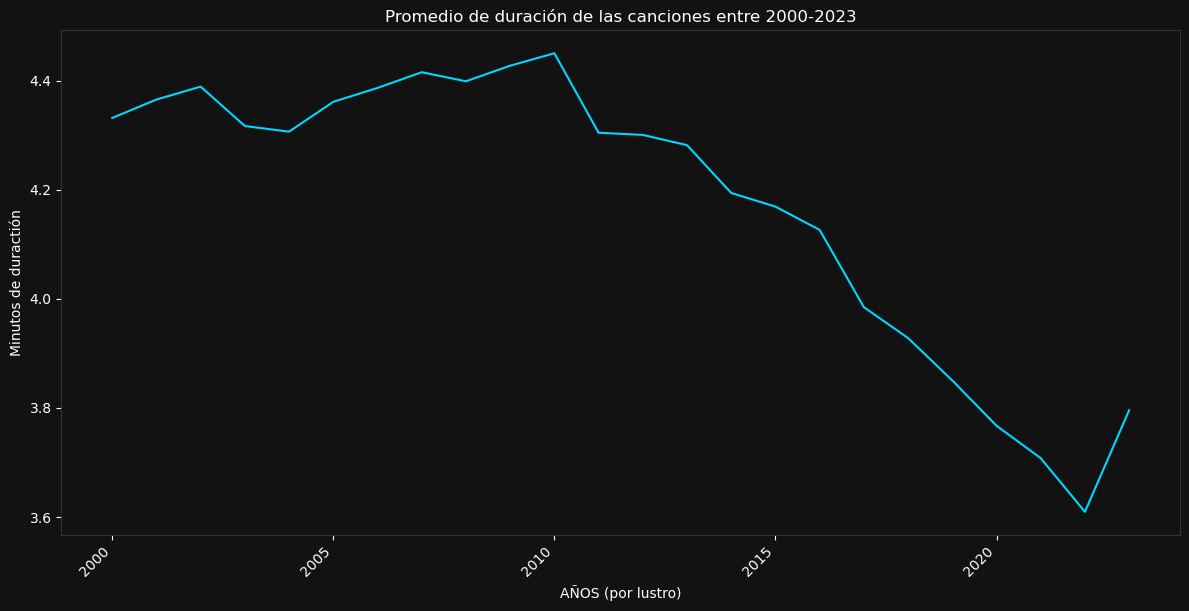

In [70]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=promedio_min,
    x="year",
    y="promedio_minutos",
    palette=['#00d8ff'],
)
plt.title('Promedio de duración de las canciones entre 2000-2023')
plt.xlabel('AÑOS (por lustro)') 
plt.ylabel('Minutos de duractión') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

En este gráfico es posible visualizar que el promedio de duración de las canciones bajó en picada a partir de finales de 2009.  
El pico más alto fue cuando el promedio era de 4:30 minutos, mientras que en 2020 el promedio fue de 3:36 minutos.  
Esto puede deberse a que en las plataformas de streaming, al solo mostrar audio y los videos musicales, se redujera la cantidad de tiempo.  
También, hay canciones que no presentan introducciones largas o los vocalistas comienzan la canción junto con la instrumental.

También se analizará el promedio del volumen de las canciones por año de forma similar a la duración de las mismas.  
Para esto, se crea una columna llamada 'avg_loudness' y se agrupará por año.  
La medida del volumen está en dB.

In [73]:
QUERY13 = """
    SELECT year, AVG(loudness) as avg_loudness
    FROM spotify_db
    GROUP BY year
    ORDER BY year ASC
    """
promedio_vol = pd.read_sql_query(QUERY13, conexion)
promedio_vol

,year,avg_loudness
0,2000,-10.148483
1,2001,-10.097640
2,2002,-9.587969
3,2003,-9.375994
4,2004,-9.109423
5,2005,-9.267861
6,2006,-9.139491
7,2007,-9.028157
8,2008,-8.763337
9,2009,-8.807054


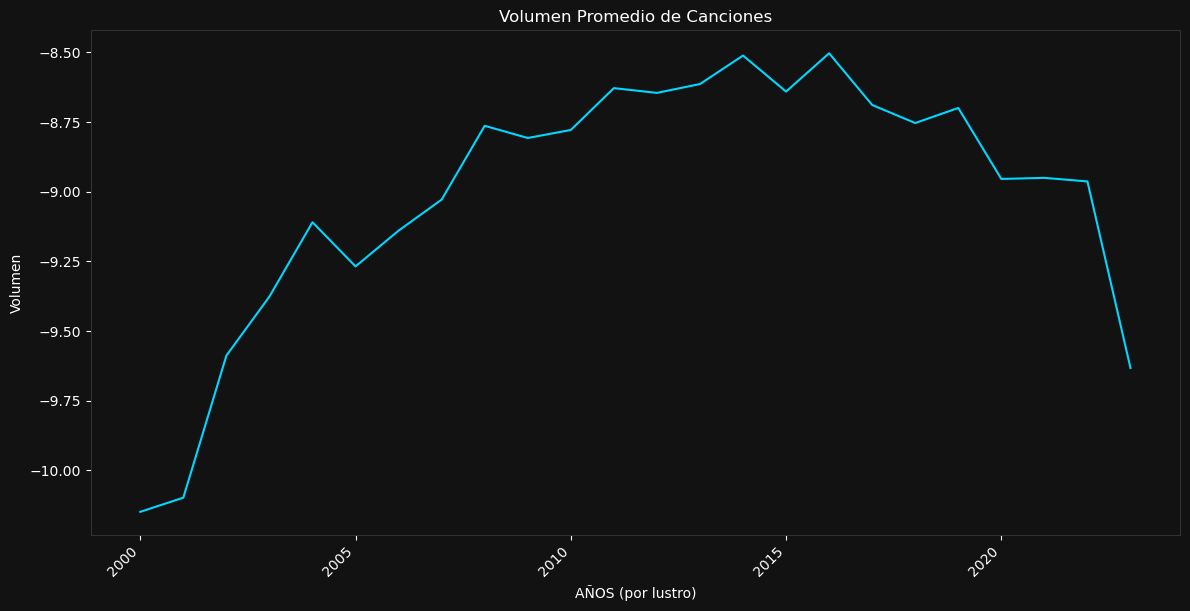

In [74]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=promedio_vol,
    x="year",
    y="avg_loudness",
    palette=['orange'],
)
plt.title('Volumen Promedio de Canciones')
plt.xlabel('AÑOS (por lustro)') 
plt.ylabel('Volumen') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

En esta gráfica es posbile visualizar que al principio del milenio, el promedio del volumen estaba por debajo de -10 dB.  
A partir del año 2002, el promedio fue creciendo con una pequeña bajada en 2005, para que luego, entre el año 2010 y 2016 las canciones tenían un volumen promedio mucho mayor, lo que se conoce como la guerra del ruido.  
Ahora bien, es notable el hecho que a finales de 2009 el promedio de duración de las canciones empezó a bajar mientras que el volumen promedio subía, lo que puede indicarnos que las canciones buscaban más retención por parte de la audencia con algo un poco más corto y más ruidoso.

En este punto, buscaremos los géneros con un volumen promedio mucho mayor que el resto, es decir, los más "ruidosos".

In [77]:
QUERY14 = """
    SELECT genre, year, AVG(loudness) as avg_loudness
    FROM spotify_db
    WHERE year BETWEEN 2000 AND 2023
      AND genre IN (
          SELECT genre 
          FROM spotify_db 
          WHERE year BETWEEN 2000 AND 2023
          GROUP BY genre 
          ORDER BY AVG(loudness) DESC 
          LIMIT 10
      )
    GROUP BY genre, year
    ORDER BY genre DESC LIMIT 20 
    """
loudest_genres = pd.read_sql_query(QUERY14, conexion)
loudest_genres

,genre,year,avg_loudness
0,reggaeton,2000,-8.278538
1,reggaeton,2001,-4.506167
2,reggaeton,2002,-4.998100
3,reggaeton,2003,-6.797548
4,reggaeton,2004,-5.574458
5,reggaeton,2005,-5.424500
6,reggaeton,2006,-5.859857
7,reggaeton,2007,-5.859921
8,reggaeton,2008,-4.869000
9,reggaeton,2009,-5.715087


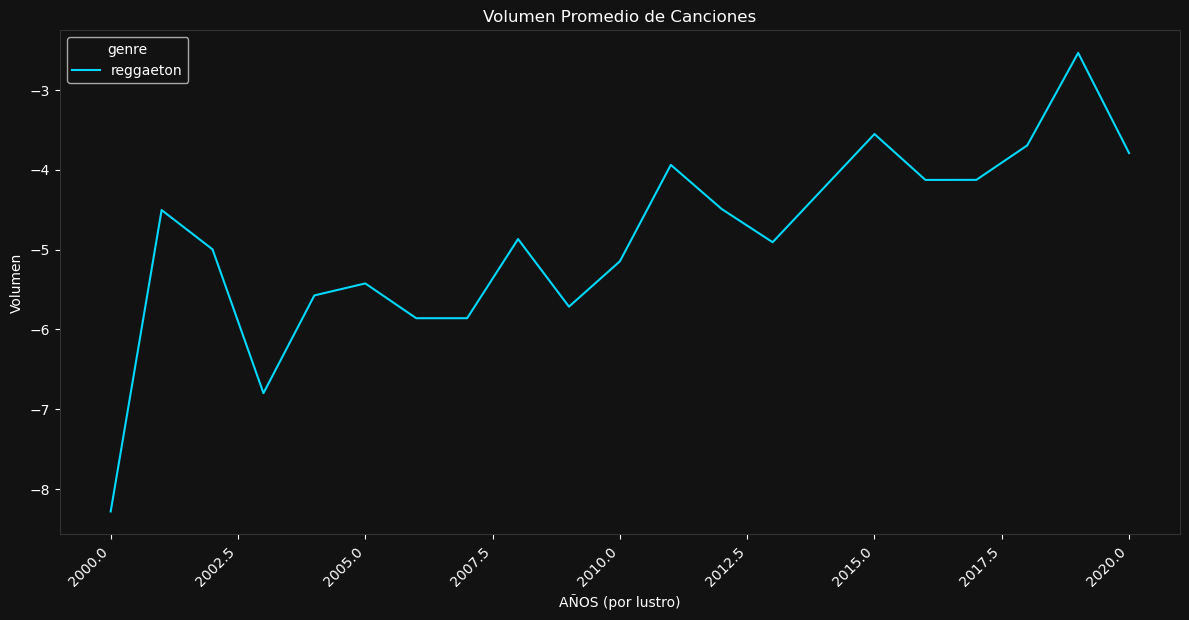

In [78]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=loudest_genres,
    x="year",
    y="avg_loudness",
    hue='genre',
    palette=['#00d8ff'],
)
plt.title('Volumen Promedio de Canciones')
plt.xlabel('AÑOS (por lustro)') 
plt.ylabel('Volumen') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

Si comparamos el volumen promedio del Punk con la gráfica anterior, notaremos que su volumen promedio es mucho más alto que el promedio visto anteriormente.
Ahora, será necesario ver cuáles eran los 10 competidores más directos del Punk en cuanto al volumen.

In [80]:
QUERY15 = """
    SELECT 
        genre, 
        year, 
        AVG(loudness) as avg_loudness
    FROM spotify_db
    WHERE year BETWEEN 2000 AND 2023
      AND genre IN (
          SELECT genre 
          FROM spotify_db 
          WHERE year BETWEEN 2000 AND 2023
            AND genre NOT LIKE '%punk%' 
          GROUP BY genre 
          ORDER BY AVG(loudness) DESC 
          LIMIT 10
      )
    GROUP BY genre, year
    ORDER BY year ASC
"""
top_ruidosos = pd.read_sql_query(QUERY15, conexion)
top_ruidosos

,genre,year,avg_loudness
0,death-metal,2000,-6.199214
1,drum-and-bass,2000,-8.571186
2,grindcore,2000,-6.256727
3,hard-rock,2000,-6.659988
4,hardcore,2000,-6.233935
...,...,...,...
233,hardstyle,2023,-4.637097
234,heavy-metal,2023,-5.549754
235,metal,2023,-5.381032
236,metalcore,2023,-5.043341


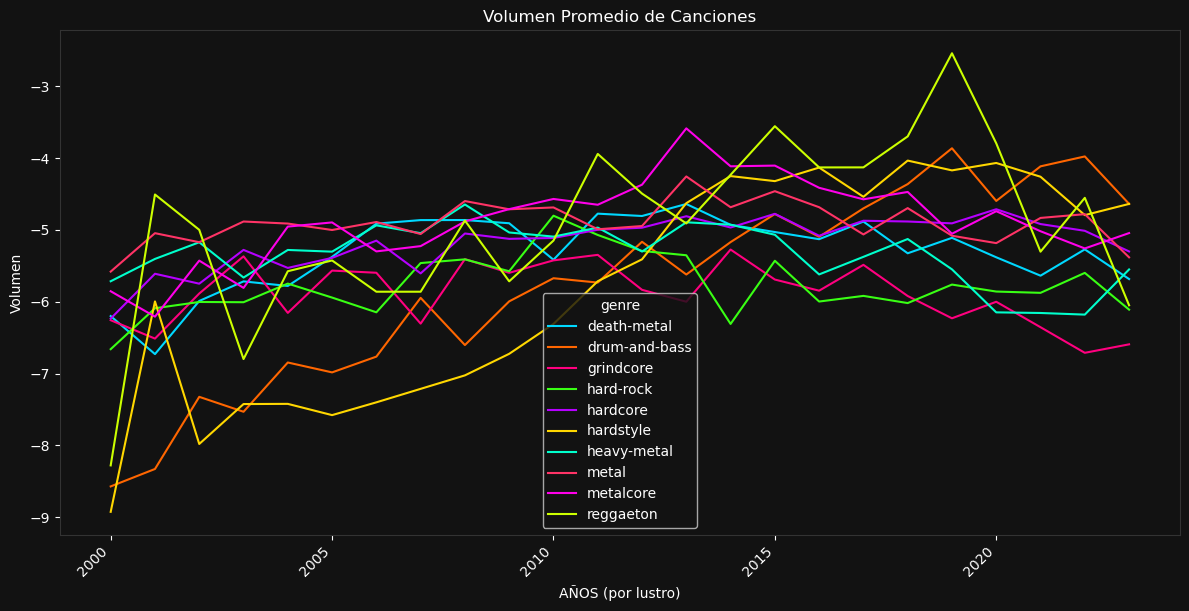

In [81]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=top_ruidosos,
    x="year",
    y="avg_loudness",
    hue='genre',
    palette=['#00d8ff', 
    '#ff6600',
    '#ff007f',
    '#39ff14',
    '#b500ff', 
    '#ffd700',
    '#00ffcc',
    '#ff3366', 
    '#ff00ea', 
    '#ccff00']
)
plt.title('Volumen Promedio de Canciones')
plt.xlabel('AÑOS (por lustro)') 
plt.ylabel('Volumen') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

Aquí podemos comprobar que los géneros más ruidosos (a excepción del ska) pertenecen a subgéneros del rock-metal y música electrónica.  
Esto puede ser explicado por la cantidad de sonidos de bajas frecuencias en ambos géneros como, guitarras eléctricas, bajos sintéticos, bombos retumbantes y sub-bajos, además que la forma de ecualizar estas canciones en su mezcla general suele resaltar esas frecuencias más bajar que hace darle mucho más cuerpo.  
Por eso, dividiremos los géneros de acuerdo a la vertiente a la que pertenezcan: rock-metal y música electrónica.

In [83]:
#grafico de death-metal, heavy-metal, hard-rock, metal-core, punk
QUERY16 = """
    SELECT genre, year, AVG(loudness) as avg_loudness 
    FROM spotify_db
    WHERE genre IN ('death-metal','heavy-metal','metalcore','punk','hard-rock')
    GROUP BY genre, year
    ORDER BY year ASC
    """
top_metal_ruidosos = pd.read_sql_query(QUERY16, conexion)
top_metal_ruidosos

,genre,year,avg_loudness
0,death-metal,2000,-6.199214
1,hard-rock,2000,-6.659988
2,heavy-metal,2000,-5.714106
3,metalcore,2000,-5.853305
4,punk,2000,-5.044600
...,...,...,...
111,death-metal,2023,-5.683555
112,hard-rock,2023,-6.109320
113,heavy-metal,2023,-5.549754
114,metalcore,2023,-5.043341


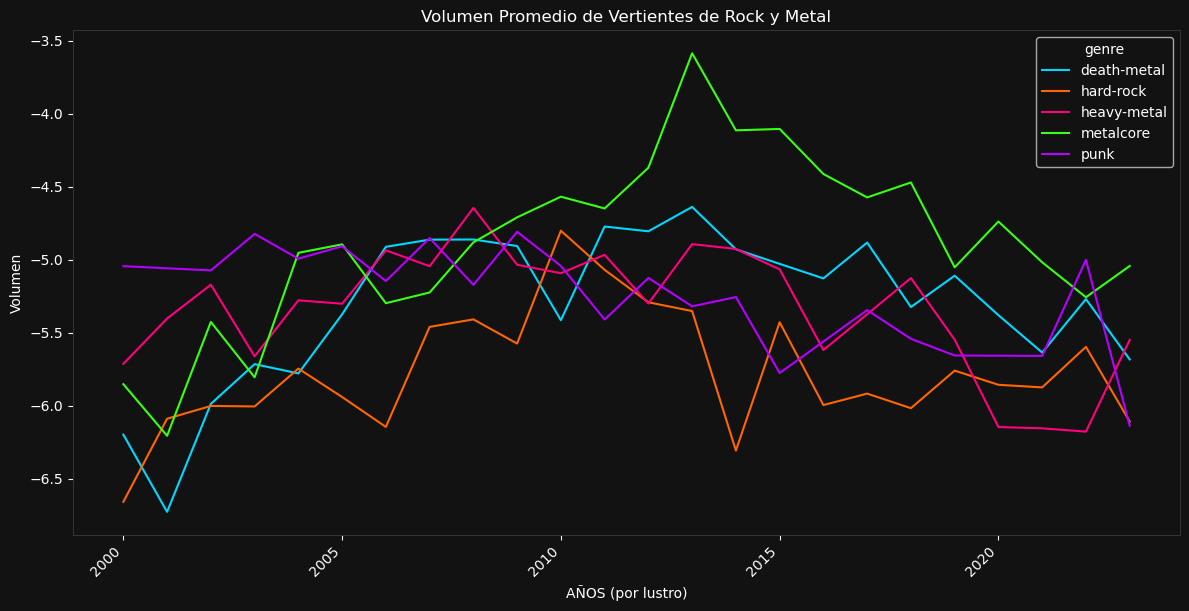

In [84]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=top_metal_ruidosos,
    x="year",
    y="avg_loudness",
    hue='genre',
    palette=['#00d8ff', # Azul neón 
    '#ff6600', # Naranja 
    '#ff007f', # Rosa cyberpunk
    '#39ff14', # Verde tóxico
    '#b500ff',]
)
plt.title('Volumen Promedio de Vertientes de Rock y Metal')
plt.xlabel('AÑOS (por lustro)') 
plt.ylabel('Volumen') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

En este punto es posible visualizar que no hay un claro dominante en cuanto al volumen promedio de las canciones ,hasta el año 2010 cuando el Metalcore se mantuvo como el género más "ruidoso" y lo fue hasta que perdió su puesto contra el Punk.  
-El Heavy-Metal por su parte siempre osciló entre -6 y -4.5.  
-Por suparte el Hard-Rock ha sido de los más discretos de estas vertientes, aunque por supuesto tuvo su pico aproximadamente en el año 2010.  
-No obstante, hay un declive general desde el 2015 del volumen promedio de todos estos subgéneros del rock-metal.

In [86]:
QUERY17 = """
    SELECT genre, year, AVG(loudness) as avg_loudness 
    FROM spotify_db
    WHERE genre IN ('drum-and-bass','grindcore','hardcore','hardstyle')
    GROUP BY genre, year
    ORDER BY year ASC
    """
top_metal_electronica = pd.read_sql_query(QUERY17, conexion)
top_metal_electronica

,genre,year,avg_loudness
0,drum-and-bass,2000,-8.571186
1,grindcore,2000,-6.256727
2,hardcore,2000,-6.233935
3,hardstyle,2000,-8.925187
4,drum-and-bass,2001,-8.328342
...,...,...,...
91,hardstyle,2022,-4.793104
92,drum-and-bass,2023,-4.636632
93,grindcore,2023,-6.592661
94,hardcore,2023,-5.298943


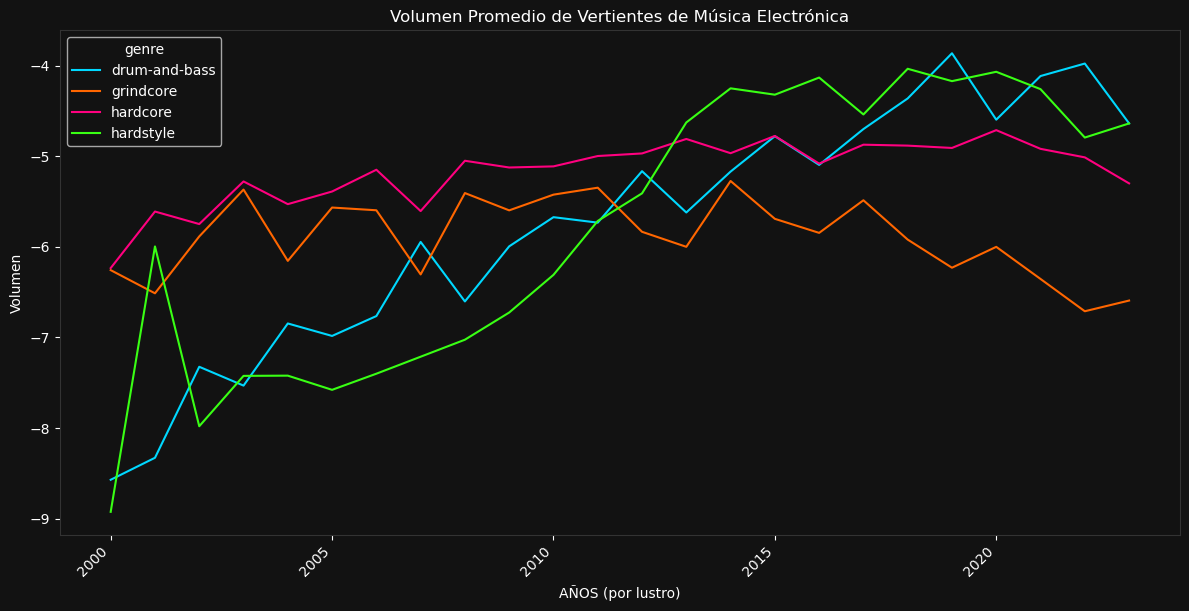

In [87]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=top_metal_electronica,
    x="year",
    y="avg_loudness",
    hue='genre',
    palette=['#00d8ff', # Azul neón 
    '#ff6600', # Naranja 
    '#ff007f', # Rosa cyberpunk
    '#39ff14',] # Verde tóxico
)
plt.title('Volumen Promedio de Vertientes de Música Electrónica')
plt.xlabel('AÑOS (por lustro)') 
plt.ylabel('Volumen') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

Los sub-géneros de música electrónica expuestos, salvo el Grindcore, mantuvieron un volumen promedio más alto que los sub-géneros del rock-metal analizados anteriormente.  
-El Grindcore ha oscilado siempre entre -6.5 y -5.5.  
-El Hardcore ha tenido una tendencia de ir subiendo poco a poco donde su registro más bajo fue justo en el 2000 estando debajo de -6 dB.  
-Por otro lado, el Drum-And-Bass (D&B) y el HardStyle han tenido una tendencia similar atrvés del tiempo y justo son los que han competido por el volumen los últimos años.

¿Qué factores hacen que una canción sea exitosa o destaque sobre otras?  
En este punto analizaremos: popularidad (popularity), bailabilidad (danceability) energía (energy), loudness (volumen), percepción o positividad (valence) y tempo o BPM (Beats per minute, golpes por minuto)  
Para esto, analizaremos la correlación entre estos factores a ver cuáles están mejor relacionados y qué tanto influyen.   
Es necesario aclarar que algunas de estas características son subjetivas como la energía, bailabilidad, popularidad y, por supuesto, la percepción.

In [90]:
QUERY18 = """
    SELECT popularity, danceability, energy, loudness, valence, tempo 
    FROM spotify_db 
    WHERE popularity IS NOT NULL 
    """
df_audio = pd.read_sql_query(QUERY18, conexion)
df_audio

,popularity,danceability,energy,loudness,valence,tempo
0,68,0.483,0.303,-10.058,0.1390,133.406
1,50,0.572,0.454,-10.286,0.5150,140.182
2,57,0.409,0.234,-13.711,0.1450,139.832
3,58,0.392,0.251,-9.845,0.5080,204.961
4,54,0.430,0.791,-5.419,0.2170,171.864
...,...,...,...,...,...,...
1159759,4,0.373,0.742,-6.453,0.5220,107.951
1159760,3,0.516,0.675,-7.588,0.2640,119.897
1159761,2,0.491,0.440,-8.512,0.0351,100.076
1159762,0,0.480,0.405,-13.343,0.2020,133.885


Analizaremos una matriz de correlación entre las variables mencionadas anteriormente con un mapa de calor (heatmap).

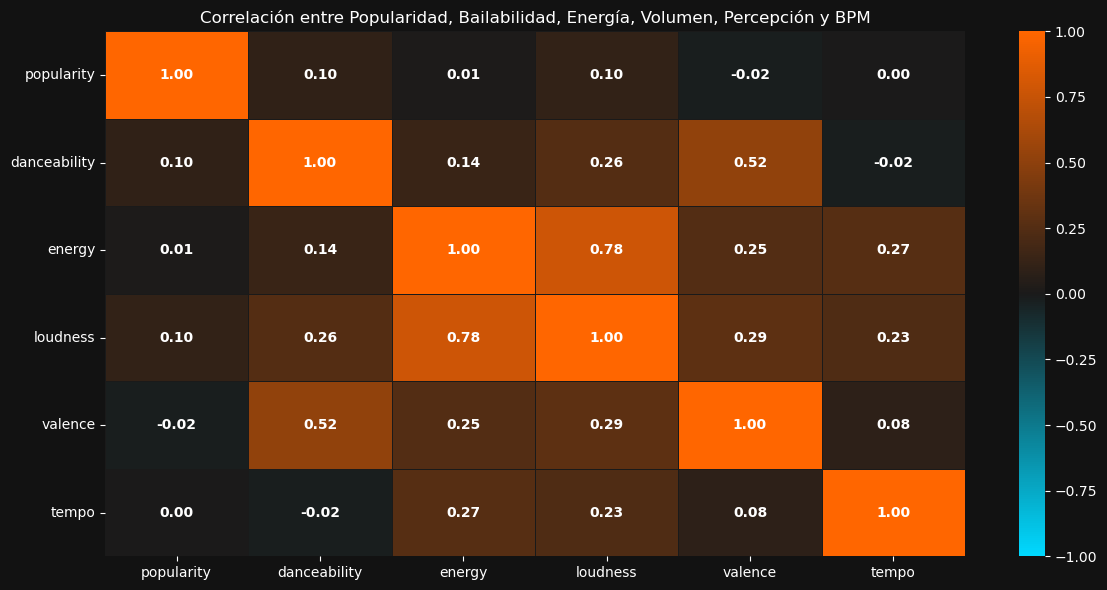

In [92]:
from matplotlib.colors import LinearSegmentedColormap

colores_neon = ['#00d8ff', '#1a1a1a', '#ff6600']
mapa_neon = LinearSegmentedColormap.from_list('estilo_portafolio', colores_neon)

matrix = df_audio.corr()
plt.figure(figsize=(12,6))
sns.heatmap(
    matrix,
    annot=True,
    cmap=mapa_neon,
    fmt='.2f', # Redondeo a 2 decimales 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
    linecolor='#1a1a1a',      
    annot_kws={"color": "white", "weight": "bold", "size": 10}
)
plt.title('Correlación entre Popularidad, Bailabilidad, Energía, Volumen, Percepción y BPM')
plt.tight_layout() 
plt.show()

Es posible observar que la Energía y el Volumen tienen una relación muy estrecha, por eso la guerra del volumen tenía sentido en su momento.  
Sin embargo, la popularidad y el volumen tienen una relación baja, sonar alto no garantiza el éxito.  
La Bailabilidad y la Percepción muestran una relación positiva moderada.  
El Tempo y la Popularidad tienen una relación neutra.

Por último, seleccionaremos los 10 géneros musicales más populares a lo largo de este siglo.

In [95]:
QUERY19 = """
    SELECT 
        genre, 
        year, 
        SUM(popularity) as total_popularity
    FROM spotify_db
    WHERE year BETWEEN 2000 AND 2023
      AND genre IN (
          SELECT genre 
          FROM spotify_db 
          WHERE year BETWEEN 2000 AND 2023
          GROUP BY genre 
          ORDER BY SUM(popularity) DESC 
          LIMIT 10
      )
    GROUP BY genre, year
    ORDER BY year ASC
"""
top_tendencias = pd.read_sql_query(QUERY19, conexion)
top_tendencias

,genre,year,total_popularity
0,alt-rock,2000,30252
1,chill,2000,384
2,country,2000,17144
3,dance,2000,26604
4,emo,2000,7614
...,...,...,...
233,folk,2023,14200
234,french,2023,21835
235,hip-hop,2023,16464
236,jazz,2023,23566


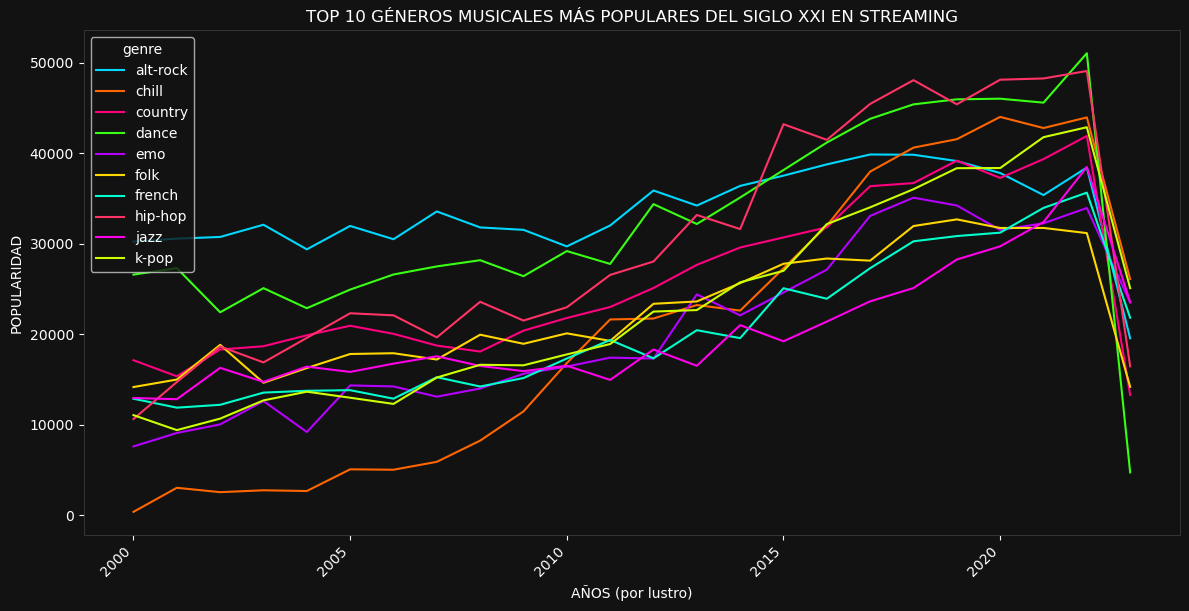

In [96]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=top_tendencias,
    x="year",
    y="total_popularity",
    hue='genre',
    palette=['#00d8ff',
    '#ff6600', 
    '#ff007f', 
    '#39ff14', 
    '#b500ff',
    '#ffd700', 
    '#00ffcc',
    '#ff3366',
    '#ff00ea', 
    '#ccff00']
)
plt.title('TOP 10 GÉNEROS MUSICALES MÁS POPULARES DEL SIGLO XXI EN STREAMING')
plt.xlabel('AÑOS (por lustro)') 
plt.ylabel('POPULARIDAD') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

En esta gráfico se destaca como hay géneros que han permanecido dentro del TOP 10 como al Alt-Rock, Country, Dance, Hip-Hop y el Jazz y la música francesa.  
Mientras se destaca poco el Chill se fue convirtiendo en tendencia poco a poco.  
Nota técnica: El desplome generalizado en el último año no representa una caída real en el consumo, sino el corte de recolección de datos de la base de datos (año incompleto), lo que reduce el volumen total acumulado frente a los años anteriores.